# SINE WAVE MODEL
This script is to develop a model to predict the sine of a value. The model is deployed to a stm32 board (nucleo-l476rg). The model is converted to a tflite model to be run with the tensorflowlite-micro tflm frame work.

## Importing the needed library

In [18]:
import os

from utils import *
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

from models.Autoencoder import Conv1DDenoiser

## Generating the dataset
The data will contain numbers between 0 and 2pi, the sine function will be defined in rad.
A random uniform error is added to the sine values to give the dataset a bit of variability and see how the model will perform.
The error is centred with a mean of 0 and std 0f 0.1. This is chosen such that 95% of the error is -0.2 and 0.+2.

In [37]:
train_samples = 1000
test_samples = 300
# Generate data
x_train, s_train = generate_data(num_samples=train_samples)
x_test, s_test = generate_data(num_samples=test_samples)

In [46]:
x_train.shape

(1, 1000, 1)

In [ ]:
x_train = x_train.reshape(1, train_samples, 1)
s_train = s_train.reshape(1, train_samples, 1)
x_test = x_test.reshape(1, test_samples, 1)
s_test = s_test.reshape(1, test_samples, 1)

In [50]:
print(x_train[0])

[[ 2.48357077e-01]
 [-6.28427173e-02]
 [ 3.36422887e-01]
 [ 7.80382233e-01]
 [-9.19214420e-02]
 [-8.56262876e-02]
 [ 8.27334300e-01]
 [ 4.27729467e-01]
 [-1.84442623e-01]
 [ 3.27855071e-01]
 [-1.68855556e-01]
 [-1.63735832e-01]
 [ 1.96383200e-01]
 [-8.74968020e-01]
 [-7.74520008e-01]
 [-1.86941528e-01]
 [-4.05953722e-01]
 [ 2.63841132e-01]
 [-3.41043166e-01]
 [-5.86936042e-01]
 [ 8.58282415e-01]
 [ 1.88071386e-02]
 [ 1.71691440e-01]
 [-5.68220162e-01]
 [-1.21816540e-01]
 [ 2.12051059e-01]
 [-4.12698277e-01]
 [ 3.56849829e-01]
 [-1.25122902e-01]
 [ 3.55382610e-02]
 [-1.13286653e-01]
 [ 1.11987984e+00]
 [ 1.93158573e-01]
 [-3.22789753e-01]
 [ 6.23488542e-01]
 [-3.92063759e-01]
 [ 3.28923206e-01]
 [-7.49219191e-01]
 [-4.27361814e-01]
 [ 3.41267803e-01]
 [ 6.18166844e-01]
 [ 3.40704217e-01]
 [ 2.03272369e-01]
 [ 1.16610768e-01]
 [-4.66042842e-01]
 [-8.06592209e-02]
 [ 5.49771806e-02]
 [ 8.19880076e-01]
 [ 4.69138981e-01]
 [-5.78191129e-01]
 [ 4.71358046e-01]
 [ 1.22749798e-01]
 [-1.7207656

In [55]:
model_name = "autoencoder_filter"

In [41]:
if model_name == "autoencoder_filter":
    model = Conv1DDenoiser()
    dummy_input = tf.random.normal([1, 1024, 1])  
    output = model(dummy_input)
    print(output.shape)
else:
    # Build the neural network
    model = Sequential([
        Dense(64, activation='relu', input_shape=(1,)),
        Dense(64, activation='relu'),
        Dense(1)
    ])

(1, 1024, 1)


/home/sergiusz/ML_Filter/.venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
model.summary()

Model: "conv1d_denoiser_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_7 (Sequential)       │ (None, None, 32)       │         4,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_8 (Sequential)       │ (1, 1024, 1)           │         4,769 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,569 (37.38 KB)

 Trainable params: 9,569 (37.38 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(x_train, s_train, epochs=100, batch_size=1)

# Evaluate the model
loss = model.evaluate(x_test, s_test)
print(f"Test Loss: {loss}")

s_pred = model.predict(x_test)




Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 981ms/step - loss: 0.5972
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.5063
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.4283
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.3560
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.2875
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.2247
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.1668
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.1137
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0690
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0387
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0276
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0338
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0495
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0644
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0694
Epoch 16/100
1/1 ━

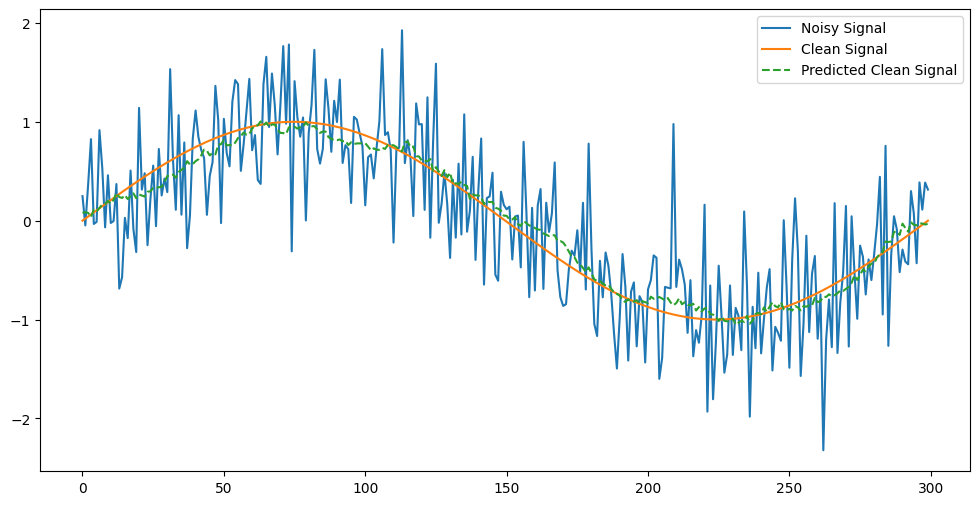

In [52]:
plt.figure(figsize=(12, 6))
plt.plot(x_test[0], label='Noisy Signal')
plt.plot(s_test[0], label='Clean Signal')
plt.plot(s_pred[0], label='Predicted Clean Signal', linestyle='dashed')
plt.legend()
plt.savefig(f'results/{model_name}.png')

## Saving the keras model

In [56]:
model.save(f'checkpoints/{model_name}.keras')


## Converting the model to tflite

In [57]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

INFO:tensorflow:Assets written to: /tmp/tmphyv_cfpu/assets


INFO:tensorflow:Assets written to: /tmp/tmphyv_cfpu/assets


Saved artifact at '/tmp/tmphyv_cfpu'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1024, 1), dtype=tf.float32, name=None)
Output Type:
  TensorSpec(shape=(None, 1024, 1), dtype=tf.float32, name=None)
Captures:
  126389882880944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126389419619280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126389419607312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126389419619808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126389883609408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126389883604656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126389883610464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126389883612576: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1758529454.044842   56876 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1758529454.044864   56876 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2025-09-22 10:24:14.045137: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmphyv_cfpu
2025-09-22 10:24:14.046113: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-09-22 10:24:14.046124: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmphyv_cfpu
2025-09-22 10:24:14.053721: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-09-22 10:24:14.095027: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmphyv_cfpu
2025-09-22 10:24:14.110287: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 65153 microseconds.


## Converting the model to the c, TFlite micro format for the microcontroller

In [ ]:
# Save as .tflite file
with open(f"results/{model_name}.tflite", "wb") as file:
    file.write(tflite_model)

# Breaking the byte in several lines to fit better in the c header file
tflite_model_split_line = np.array_split([format(hex_value, '#04x') for hex_value in tflite_model], len(tflite_model)//8)

C_HEADER_DIR = "STM_project"
newline = ",\n    "  # separator to avoid new line character

# Write TfLite model to a C header file
open(f"{C_HEADER_DIR}/{model_name.lower()}.h", "w").write(
f"""
#ifndef {model_name.upper()}_H
#define {model_name.upper()}_H

const unsigned int {model_name.lower()}_len = {len(tflite_model)};

const unsigned char {model_name.lower()}[{len(tflite_model)}] = {{
    {newline.join([", ".join(line) for line in tflite_model_split_line])}
}};

#endif // {model_name.upper()}_H
"""
)


108720

## Testing the converted tflite model

In [ ]:
interpreter = tf.lite.Interpreter(model_path=f"{model_name}.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

y_test_tflite_predict = []
for x_ in x_test:
  # Set input tensor
  interpreter.set_tensor(input_details[0]['index'], np.array([[x_]], dtype=np.float32))

  # Run the inference
  interpreter.invoke()

  y_test_tflite_predict.append(interpreter.get_tensor(output_details[0]['index']))

y_test_tflite_predict = np.array(y_test_tflite_predict)


In [ ]:
y_test_predict = model.predict(x_test)
s_test_true = np.sin(x_test)

mae_orginal_model = np.sum(np.abs(s_test_predict - s_test)) / y_test.shape[0]
mae_converted_model = np.sum(np.abs(y_test_tflite_predict - y_test)) / y_test.shape[0]

fig, axes = plt.subplots(1, 2, figsize=(16,6))

axes[0].scatter(x_test, y_test_tflite_predict, marker=".", label="True value")
axes[0].scatter(x_test, y_test_true, marker=".", label="Predicted value")
axes[0].set_title("Prediction and True Values")
axes[0].set_ylabel("sin(x)")
axes[0].set_xlabel("x")
axes[0].legend()

axes[1].bar(["orginal model", "converted model"], [mae_orginal_model, mae_converted_model])
axes[1].set_title("The effect of coversion to model accuracy")
axes[1].set_ylabel("mae")
axes[1].set_xlabel("model type")

plt.show()